<a href="https://colab.research.google.com/github/marceleazoliveira/TF_IA/blob/main/TF_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Ellipse, Polygon

In [16]:
# Configurações gerais

# São 5 classes de forma, com 5 objetos de cada classe
N_POR_CLASSE = 5

cores = ["red", "green", "blue"]

# Formas adaptadas para o cenário 2D
# cylinder -> ellipse
# cone -> rectangle
formas = ["circle", "square", "ellipse", "rectangle", "triangle"]

# Total de objetos: 5 classes * 5 objetos por classe = 25
N_OBJETOS = len(formas) * N_POR_CLASSE

# Tamanhos: 1x1, 2x2, 3x3
tamanhos = [1, 2, 3]

# Tamanho visual usado no gráfico
BASE_VISUAL = 0.018

In [28]:
def criar_vetor(objeto):
    """
    Cria o vetor de características do objeto.

    Estrutura:
    [0, 1]            -> x, y
    [2, 3, 4]         -> cor one-hot: red, green, blue
    [5, 6, 7, 8, 9]   -> forma one-hot: circle, square, ellipse, rectangle, triangle
    [10]              -> tamanho normalizado
    """

    x = objeto["x"]
    y = objeto["y"]

    # One-hot da cor
    cor_one_hot = [0, 0, 0]
    indice_cor = cores.index(objeto["cor"])
    cor_one_hot[indice_cor] = 1

    # One-hot da forma
    forma_one_hot = [0, 0, 0, 0, 0]
    indice_forma = formas.index(objeto["forma"])
    forma_one_hot[indice_forma] = 1

    # Tamanho normalizado
    # 1x1 -> 1/3
    # 2x2 -> 2/3
    # 3x3 -> 1
    tamanho_normalizado = objeto["tamanho"] / 3

    vetor = [x, y] + cor_one_hot + forma_one_hot + [tamanho_normalizado]

    return vetor


def dimensoes_objeto(forma, tamanho):
    escala = BASE_VISUAL * tamanho

    if forma == "circle":
        largura = 2 * escala
        altura = 2 * escala

    elif forma == "square":
        largura = 2 * escala
        altura = 2 * escala

    elif forma == "rectangle":
        largura = 2.8 * escala
        altura = 1.4 * escala

    elif forma == "ellipse":
        largura = 3.0 * escala
        altura = 1.5 * escala

    elif forma == "triangle":
        largura = 2.4 * escala
        altura = 2.3 * escala

    return largura, altura


def tem_sobreposicao(x, y, forma, tamanho, objetos, margem=0.015):
    largura, altura = dimensoes_objeto(forma, tamanho)

    for obj in objetos:
        largura2, altura2 = dimensoes_objeto(obj["forma"], obj["tamanho"])

        distancia_x = abs(x - obj["x"])
        distancia_y = abs(y - obj["y"])

        limite_x = (largura / 2) + (largura2 / 2) + margem
        limite_y = (altura / 2) + (altura2 / 2) + margem

        if distancia_x < limite_x and distancia_y < limite_y:
            return True

    return False


def gerar_objetos(n_por_classe=5):
    """
    Gera uma cena com 5 classes de objetos e n_por_classe objetos por classe.

    Exemplo:
    5 círculos
    5 quadrados
    5 elipses
    5 retângulos
    5 triângulos

    Total: 25 objetos.
    """

    objetos = []

    # Garante exatamente 5 objetos de cada classe
    formas_da_cena = []

    for forma in formas:
        for _ in range(n_por_classe):
            formas_da_cena.append(forma)

    # Embaralha para a ordem dos objetos na cena ficar aleatória
    np.random.shuffle(formas_da_cena)

    tentativas = 0
    max_tentativas = 30000

    indice_forma = 0

    while len(objetos) < len(formas_da_cena) and tentativas < max_tentativas:
        tentativas += 1

        forma = formas_da_cena[indice_forma]
        cor = np.random.choice(cores)
        tamanho = int(np.random.choice(tamanhos))

        largura, altura = dimensoes_objeto(forma, tamanho)

        # Evita gerar objetos cortados nas bordas
        x = float(np.random.uniform(largura / 2, 1 - largura / 2))
        y = float(np.random.uniform(altura / 2, 1 - altura / 2))

        # Evita overlapping
        if tem_sobreposicao(x, y, forma, tamanho, objetos):
            continue

        objeto = {
            "id": len(objetos),
            "x": x,
            "y": y,
            "cor": cor,
            "forma": forma,
            "tamanho": tamanho,
            "tamanho_nome": f"{tamanho}x{tamanho}"
        }

        objeto["vetor"] = criar_vetor(objeto)

        objetos.append(objeto)

        # Só passa para a próxima forma quando o objeto atual foi aceito
        indice_forma += 1

    if len(objetos) < len(formas_da_cena):
        print(f"Aviso: só consegui gerar {len(objetos)} objetos sem sobreposição.")

    return objetos

In [18]:
# Cena de treino: uma única "imagem" com 25 objetos
objetos = gerar_objetos(n_por_classe=N_POR_CLASSE)

df = pd.DataFrame(objetos)

df[["id", "x", "y", "cor", "forma", "tamanho_nome", "vetor"]]

,id,x,y,cor,forma,tamanho_nome,vetor
0,0,0.573663,0.634355,green,circle,3x3,"[0.5736627609351508, 0.6343549435098277, 0, 1,..."
1,1,0.636905,0.386297,blue,square,1x1,"[0.6369045037161192, 0.3862966411595622, 0, 0,..."
2,2,0.319230,0.898451,red,square,2x2,"[0.3192301142261801, 0.898450783569436, 1, 0, ..."
3,3,0.483977,0.400245,red,circle,3x3,"[0.48397696656193906, 0.40024463028790164, 1, ..."
4,4,0.893582,0.265055,blue,rectangle,1x1,"[0.8935818417981519, 0.26505535731752256, 0, 0..."
5,5,0.365554,0.074236,green,square,2x2,"[0.3655540306676789, 0.07423648231507929, 0, 1..."
6,6,0.769795,0.440464,red,ellipse,2x2,"[0.7697947866565977, 0.4404642551786473, 1, 0,..."
7,7,0.168402,0.612960,green,rectangle,1x1,"[0.16840249917654335, 0.6129598522054123, 0, 1..."
8,8,0.179930,0.444686,red,triangle,3x3,"[0.17993037230416847, 0.4446864425091519, 1, 0..."
9,9,0.752624,0.170370,green,circle,2x2,"[0.7526243755320118, 0.17037000501230612, 0, 1..."


In [19]:
def plotar_cenario(objetos):
    plt.figure(figsize=(8, 6))
    ax = plt.gca()

    for obj in objetos:
        x = obj["x"]
        y = obj["y"]
        cor = obj["cor"]
        forma = obj["forma"]
        tamanho = obj["tamanho"]

        escala = BASE_VISUAL * tamanho

        if forma == "circle":
            patch = Circle(
                (x, y),
                radius=escala,
                facecolor=cor,
                edgecolor="black"
            )

        elif forma == "square":
            patch = Rectangle(
                (x - escala, y - escala),
                2 * escala,
                2 * escala,
                facecolor=cor,
                edgecolor="black"
            )

        elif forma == "rectangle":
            patch = Rectangle(
                (x - 1.4 * escala, y - 0.7 * escala),
                2.8 * escala,
                1.4 * escala,
                facecolor=cor,
                edgecolor="black"
            )

        elif forma == "ellipse":
            patch = Ellipse(
                (x, y),
                width=3.0 * escala,
                height=1.5 * escala,
                facecolor=cor,
                edgecolor="black"
            )

        elif forma == "triangle":
            vertices = [
                (x, y + 1.3 * escala),
                (x - 1.2 * escala, y - escala),
                (x + 1.2 * escala, y - escala)
            ]

            patch = Polygon(
                vertices,
                closed=True,
                facecolor=cor,
                edgecolor="black"
            )

        ax.add_patch(patch)
        ax.text(x + 0.01, y + 0.01, str(obj["id"]), fontsize=9)

    plt.title("Cenário CLEVR simplificado com 25 objetos sem overlapping")
    plt.xlabel("posição x")
    plt.ylabel("posição y")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()

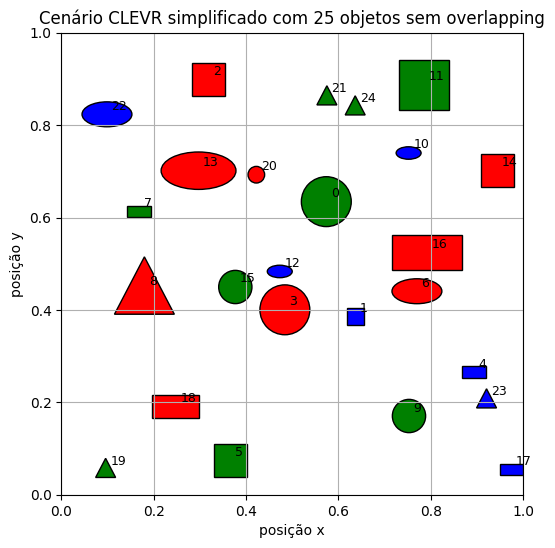

In [20]:
plotar_cenario(objetos)

In [21]:
def left_of(a, b):
    return a["x"] < b["x"]


def right_of(a, b):
    return a["x"] > b["x"]


def below(a, b):
    return a["y"] < b["y"]


def above(a, b):
    return a["y"] > b["y"]


def close_to(a, b, threshold=0.20):
    distancia = np.sqrt((a["x"] - b["x"])**2 + (a["y"] - b["y"])**2)
    return distancia < threshold


def same_size(a, b):
    return a["tamanho"] == b["tamanho"]


def in_between_horizontal(x, y, z):
    return min(y["x"], z["x"]) < x["x"] < max(y["x"], z["x"])


def in_between_vertical(x, y, z):
    return min(y["y"], z["y"]) < x["y"] < max(y["y"], z["y"])


def in_between(x, y, z):
    return in_between_horizontal(x, y, z) or in_between_vertical(x, y, z)

In [22]:
a = objetos[0]
b = objetos[1]

print("Objeto 0:", a)
print("Objeto 1:", b)

print("\nRelações:")
print("0 está à esquerda de 1?", left_of(a, b))
print("0 está à direita de 1?", right_of(a, b))
print("0 está abaixo de 1?", below(a, b))
print("0 está acima de 1?", above(a, b))
print("0 está próximo de 1?", close_to(a, b))
print("0 tem mesmo tamanho que 1?", same_size(a, b))

Objeto 0: {'id': 0, 'x': 0.5736627609351508, 'y': 0.6343549435098277, 'cor': np.str_('green'), 'forma': 'circle', 'tamanho': 3, 'tamanho_nome': '3x3', 'vetor': [0.5736627609351508, 0.6343549435098277, 0, 1, 0, 1, 0, 0, 0, 0, 1.0]}
Objeto 1: {'id': 1, 'x': 0.6369045037161192, 'y': 0.3862966411595622, 'cor': np.str_('blue'), 'forma': 'square', 'tamanho': 1, 'tamanho_nome': '1x1', 'vetor': [0.6369045037161192, 0.3862966411595622, 0, 0, 1, 0, 1, 0, 0, 0, 0.3333333333333333]}

Relações:
0 está à esquerda de 1? True
0 está à direita de 1? False
0 está abaixo de 1? False
0 está acima de 1? True
0 está próximo de 1? False
0 tem mesmo tamanho que 1? False


In [23]:
def gerar_tabela_pares(objetos):
    pares = []

    for i in range(len(objetos)):
        for j in range(len(objetos)):
            if i != j:
                a = objetos[i]
                b = objetos[j]

                pares.append({
                    "objeto_a": a["id"],
                    "objeto_b": b["id"],

                    "forma_a": a["forma"],
                    "forma_b": b["forma"],

                    "cor_a": a["cor"],
                    "cor_b": b["cor"],

                    "tamanho_a": a["tamanho_nome"],
                    "tamanho_b": b["tamanho_nome"],

                    "left_of": left_of(a, b),
                    "right_of": right_of(a, b),
                    "below": below(a, b),
                    "above": above(a, b),
                    "close_to": close_to(a, b),
                    "same_size": same_size(a, b)
                })

    return pd.DataFrame(pares)


df_pares = gerar_tabela_pares(objetos)

df_pares.head(10)

,objeto_a,objeto_b,forma_a,forma_b,cor_a,cor_b,tamanho_a,tamanho_b,left_of,right_of,below,above,close_to,same_size
0,0,1,circle,square,green,blue,3x3,1x1,True,False,False,True,False,False
1,0,2,circle,square,green,red,3x3,2x2,False,True,True,False,False,False
2,0,3,circle,circle,green,red,3x3,3x3,False,True,False,True,False,True
3,0,4,circle,rectangle,green,blue,3x3,1x1,True,False,False,True,False,False
4,0,5,circle,square,green,green,3x3,2x2,False,True,False,True,False,False
5,0,6,circle,ellipse,green,red,3x3,2x2,True,False,False,True,False,False
6,0,7,circle,rectangle,green,green,3x3,1x1,False,True,False,True,False,False
7,0,8,circle,triangle,green,red,3x3,3x3,False,True,False,True,False,True
8,0,9,circle,circle,green,green,3x3,2x2,True,False,False,True,False,False
9,0,10,circle,ellipse,green,blue,3x3,1x1,True,False,True,False,False,False


In [24]:
def gerar_tabela_trios(objetos):
    trios = []

    for i in range(len(objetos)):
        for j in range(len(objetos)):
            for k in range(len(objetos)):
                if i != j and i != k and j != k:
                    x = objetos[i]
                    y = objetos[j]
                    z = objetos[k]

                    trios.append({
                        "objeto_x": x["id"],
                        "objeto_y": y["id"],
                        "objeto_z": z["id"],

                        "forma_x": x["forma"],
                        "forma_y": y["forma"],
                        "forma_z": z["forma"],

                        "cor_x": x["cor"],
                        "cor_y": y["cor"],
                        "cor_z": z["cor"],

                        "in_between": in_between(x, y, z),
                        "in_between_horizontal": in_between_horizontal(x, y, z),
                        "in_between_vertical": in_between_vertical(x, y, z)
                    })

    return pd.DataFrame(trios)


df_trios = gerar_tabela_trios(objetos)

df_trios.head(10)

,objeto_x,objeto_y,objeto_z,forma_x,forma_y,forma_z,cor_x,cor_y,cor_z,in_between,in_between_horizontal,in_between_vertical
0,0,1,2,circle,square,square,green,blue,red,True,True,True
1,0,1,3,circle,square,circle,green,blue,red,True,True,False
2,0,1,4,circle,square,rectangle,green,blue,blue,False,False,False
3,0,1,5,circle,square,square,green,blue,green,True,True,False
4,0,1,6,circle,square,ellipse,green,blue,red,False,False,False
5,0,1,7,circle,square,rectangle,green,blue,green,True,True,False
6,0,1,8,circle,square,triangle,green,blue,red,True,True,False
7,0,1,9,circle,square,circle,green,blue,green,False,False,False
8,0,1,10,circle,square,ellipse,green,blue,blue,True,False,True
9,0,1,11,circle,square,square,green,blue,green,True,False,True


In [25]:
def calcular_metricas(y_true, y_pred):
    """
    Calcula Accuracy, Precision, Recall e F1 Score.
    """

    y_true = np.array(y_true).astype(bool)
    y_pred = np.array(y_pred).astype(bool)

    TP = np.sum((y_true == True) & (y_pred == True))
    TN = np.sum((y_true == False) & (y_pred == False))
    FP = np.sum((y_true == False) & (y_pred == True))
    FN = np.sum((y_true == True) & (y_pred == False))

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0

    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    return {
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [26]:
relacoes_pares = ["left_of", "right_of", "below", "above", "close_to", "same_size"]

resultados_metricas = []

for relacao in relacoes_pares:
    metricas = calcular_metricas(
        y_true=df_pares[relacao],
        y_pred=df_pares[relacao]
    )

    metricas["relacao"] = relacao
    resultados_metricas.append(metricas)

df_metricas_pares = pd.DataFrame(resultados_metricas)

df_metricas_pares[
    ["relacao", "TP", "TN", "FP", "FN", "Accuracy", "Precision", "Recall", "F1"]
]

,relacao,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
0,left_of,300,300,0,0,1.0,1.0,1.0,1.0
1,right_of,300,300,0,0,1.0,1.0,1.0,1.0
2,below,300,300,0,0,1.0,1.0,1.0,1.0
3,above,300,300,0,0,1.0,1.0,1.0,1.0
4,close_to,48,552,0,0,1.0,1.0,1.0,1.0
5,same_size,196,404,0,0,1.0,1.0,1.0,1.0


In [27]:
metricas_in_between = calcular_metricas(
    y_true=df_trios["in_between"],
    y_pred=df_trios["in_between"]
)

metricas_in_between

{'TP': np.int64(7572),
 'TN': np.int64(6228),
 'FP': np.int64(0),
 'FN': np.int64(0),
 'Accuracy': np.float64(1.0),
 'Precision': np.float64(1.0),
 'Recall': np.float64(1.0),
 'F1': np.float64(1.0)}